## Imports

In [1]:
print('Hello World!')

Hello World!


In [2]:
!pip install optuna_dashboard

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ---------------------------------------- 8.4/8.4 MB 86.6 MB/s  0:00:00

   -------------------- ------------------- 1/2 [optuna_dashboard]
   ---------------------------------------- 2/2 [optuna_dashboard]



In [1]:
#this is run with a python 3.9.6 installation
from optuna_dashboard import run_server
import optuna

from math import isnan, log

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import to_rgba

import numpy as np

from copy import deepcopy


import pickle

c:\Users\richa\miniconda3\envs\hpvsim310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Code for running Optuna dashboard for interacting with a calibration

In [15]:
name ="CalibrationRawResults/Jan25_1"  #"CalibrationRawResults/Jan7_3" # "CalibrationRawResults/Jan7_2"

In [14]:
#Running dashboard
run_server(f'sqlite:///{name}.db', host="127.0.0.1", port = 8083)


Bottle v0.13.4 server starting up (using WSGIRefServer())...
Listening on http://127.0.0.1:8083/
Hit Ctrl-C to quit.

127.0.0.1 - - [04/Mar/2026 19:48:11] "GET / HTTP/1.1" 302 0
127.0.0.1 - - [04/Mar/2026 19:48:13] "GET /api/meta HTTP/1.1" 200 114
127.0.0.1 - - [04/Mar/2026 19:48:13] "GET /api/studies HTTP/1.1" 200 157
127.0.0.1 - - [04/Mar/2026 19:48:39] "GET /api/studies/1/param_importances HTTP/1.1" 200 1323
127.0.0.1 - - [04/Mar/2026 19:48:41] "GET /api/studies/1?after=0 HTTP/1.1" 200 18710128
127.0.0.1 - - [04/Mar/2026 19:48:54] "GET /api/studies/1?after=0 HTTP/1.1" 200 18710128
127.0.0.1 - - [04/Mar/2026 19:48:54] "GET /api/studies/1/param_importances HTTP/1.1" 200 1323
127.0.0.1 - - [04/Mar/2026 19:48:56] "GET /api/studies/1?after=5000 HTTP/1.1" 200 7448
127.0.0.1 - - [04/Mar/2026 19:48:59] "GET /api/studies/1?after=0 HTTP/1.1" 200 18710128
127.0.0.1 - - [04/Mar/2026 19:49:20] "GET /api/studies/1?after=5000 HTTP/1.1" 200 7448
127.0.0.1 - - [04/Mar/2026 19:49:22] "GET /api/studie

## Code for saving a csv of the samples from a calibration

In [4]:
#Loading calibration and saving a CSV of our trials
loaded_study = optuna.load_study(study_name=f'{name}', storage=f'sqlite:///{name}.db')
loaded_study = loaded_study.trials_dataframe().sort_values('value')
loaded_study.to_csv(f"{name}.csv")

## Loading in all 3 calibrations and plotting the best of them, including for further analysis

In [ ]:
#Core variables for following cells in this file
cal_names = ["CalibrationRawResults/Jan7_4", 
             "CalibrationRawResults/Jan7_3", 
             "CalibrationRawResults/Jan7_2"]

par_labels = ['params_hpv16_cin_fn_k',
                'params_hi5_rel_beta',
                'params_ohr_dur_cin_par1',
                'params_hpv18_cin_fn_k',
                'params_ohr_cin_fn_k',
                'params_hi5_dur_cin_par1',
                'params_m_cross_layer',
                'params_f_cross_layer',
                'params_ohr_rel_beta',
                'params_hpv18_dur_cin_par1',
                'params_hpv16_dur_cin_par1',
                'params_hi5_cin_fn_k',
                'params_beta']

K = 0.005 * (5000*3) ;K=int(K) #This is the number of trials we 'skim from the bottom' of our GOFs

grey_bad_gofs = True #if True, makesa all but the top K GOFs a bit transparent when plotting them

In [ ]:
#Produces 'combined_cal_data', a list of tuples (pars, GOF, order statistic of this GOF within the calibration that sampled these pars, ID of this calibration),
#    where pars is a tuple of the parameterisation values for this calibration, ordered as in par_labels

combined_cal_data = []

for cal_index in range(len(cal_names)):
    #Load calibration results
    cal_name = cal_names[cal_index]
    loaded_study = optuna.load_study(study_name=f'{cal_name}', storage=f'sqlite:///{cal_name}.db')
    loaded_study = loaded_study.trials_dataframe()

    #Collect up a list of tuples [(par tuple), (GOF)], ordered by decreasing GOF, with par tuples defining values in order of par_labels
    cal_results = []
    for row in range(len(loaded_study)):
        cal_result = loaded_study.iloc[[row]]

        par_list = []
        for par_label in par_labels:
            par_list.append(cal_result[par_label].item())
        par_tuple = tuple(par_list)

        gof = cal_result['value'].item()

        if not isnan(gof): #gof will be none if a trial failed; catches this
            cal_results.append((par_tuple, gof))

    cal_results = sorted(cal_results, key=lambda x:x[1])

    cal_results_with_order_statistics = []
    for i in range(len(cal_results)):
        pars, gof = cal_results[i]
        crwos_tuple = (pars, gof, i, cal_index)
        cal_results_with_order_statistics.append(crwos_tuple)

    combined_cal_data += cal_results_with_order_statistics

combined_cal_data = sorted(combined_cal_data, key=lambda x:x[1])

In [5]:
#Plots the GOFs along each axis of our parameter space, as sampled across our 3 calibrations

def order_to_point_size(n, scale=25):
    return (n+1)**(-0.5)*scale

def gof_transform(gof, shift=14):
    return log(gof-shift)

def color_transform(color_index, grey_out = False):
    alpha=1 if not grey_out else 0.07

    if color_index == 0:
        return to_rgba('mediumblue', alpha=alpha)
    elif color_index == 1:
        return to_rgba('orange', alpha=alpha)
    elif color_index == 2:
        return to_rgba('fuchsia', alpha=alpha)
    else:
        return 'grey'

if grey_bad_gofs:
    colour_plot_data = combined_cal_data[:K] #assumes sorted by GOF
    grey_plot_data = combined_cal_data[K:]
else:
    colour_plot_data = combined_cal_data
    grey_plot_data = []

for param_index in range(13):
    #Coloured data
    xs = list(map(lambda pgic:pgic[0][param_index], colour_plot_data)) #param values
    ys = list(map(lambda pgic:gof_transform(pgic[1]), colour_plot_data)) #gof values
    point_sizes = list(map(lambda pgic:order_to_point_size(pgic[2]), colour_plot_data)) #size the point should be (according to order within the calibration the trial came from)
    colors = list(map(lambda pgic:color_transform(pgic[3]), colour_plot_data)) #calibration the trial came from

    plt.scatter(xs, ys, s=point_sizes, c=colors)
    
    #Greyed out data
    xs = list(map(lambda pgic:pgic[0][param_index], grey_plot_data)) #param values
    ys = list(map(lambda pgic:gof_transform(pgic[1]), grey_plot_data)) #gof values
    point_sizes = list(map(lambda pgic:order_to_point_size(pgic[2]), grey_plot_data)) #size the point should be (according to order within the calibration the trial came from)
    colors = list(map(lambda pgic:color_transform(pgic[3], grey_out=True), grey_plot_data)) #calibration the trial came from

    plt.scatter(xs, ys, s=point_sizes, c=colors)


    plt.title(f"{par_labels[param_index][7:]} marginal")
    plt.yticks(list(map(gof_transform, [14.4,15,16,20,50,100,1000])), ['14.4','15','16', '20','50', '100', '1000'])
    plt.show()

NameError: name 'grey_bad_gofs' is not defined

## Comparing similarities of top K parameters and filtering to get final cal data

In [ ]:
#Specify the minimum distance between parameterisations for them not to be considered as overlapping each other
min_GNPD = 0.05

In [ ]:
#Compute the distances between each pair of parametersations, of the top K

unfiltered_cal_data = combined_cal_data[:K] #assumes sorted by GOF

#Specify search range of each parameterisation, to rescale correctly
parameter_range_by_par = {'params_hpv16_cin_fn_k':1-0,
                            'params_hi5_rel_beta':1-0,
                            'params_ohr_dur_cin_par1':12-1,
                            'params_hpv18_cin_fn_k':1-0,
                            'params_ohr_cin_fn_k':1-0,
                            'params_hi5_dur_cin_par1':12-1,
                            'params_m_cross_layer':1-0,
                            'params_f_cross_layer':1-0,
                            'params_ohr_rel_beta':1-0,
                            'params_hpv18_dur_cin_par1':12-1,
                            'params_hpv16_dur_cin_par1':12-1,
                            'params_hi5_cin_fn_k':1-0,
                            'params_beta':0.5-0,
}

#Generate GNPD scores
GNPD_grid = np.full((K,K), np.nan)
for i in range(K):
    #Populate diagonal
    GNPD_grid[i,i] = 0
    #Populate lower triangular matrix
    for j in range(i):
        l1_diff = 0
        for par_label_i in range(len(par_labels)):
            par_label = par_labels[par_label_i]
            candidate_l1_diff = np.abs(unfiltered_cal_data[i][0][par_label_i] - unfiltered_cal_data[j][0][par_label_i]) / parameter_range_by_par[par_label]
            l1_diff = candidate_l1_diff if candidate_l1_diff>l1_diff else l1_diff
        GNPD_grid[i,j] = l1_diff
#Populate upper triangular matrix by copying values
for i in range(K):
    for j in range(i+1, K):
        GNPD_grid[i,j] = GNPD_grid[j,i]

/var/folders/zv/s824tx9n4x7fz_rn2vwjt13w0000gs/T/ipykernel_4300/4190020833.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_custom = cm.get_cmap('Blues').copy()


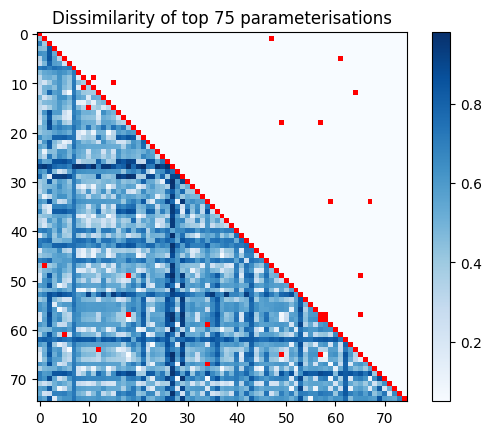

In [ ]:
#Do a plot to highlight 'clashing' parameterisations


cmap_custom = cm.get_cmap('Blues').copy()
cmap_custom.set_under('red')
vmin = min_GNPD

#To clarify colourmap, take away all blues from upper triangular matrix
toplot = deepcopy(GNPD_grid)
for i in range(K):
    for j in range(i+1,K):
        if toplot[i,j] > vmin:
            toplot[i,j] = vmin

plt.imshow(toplot,cmap=cmap_custom, vmin=vmin)
plt.colorbar()
plt.title(f"Dissimilarity of top {K} parameterisations")
plt.show()

In [ ]:
#Get final cal data, filtering out the clashing parameterisations
final_cal_data = []

#Iterate over all top K parameterisations
for i in range(K):
    include = True

    #Check against all proceeding (higher GOF) parameterisations
    for j in range(i):
        if GNPD_grid[i,j]<min_GNPD:
            include = False

    if include:
        final_cal_data.append(unfiltered_cal_data[i])

print(f"We have finished with {len(final_cal_data)} final calibrated parameterisations")

We have finished with 64 final calibrated parameterisations


## Save final calibration

In [ ]:
savedata = {'final_cal_data': final_cal_data,
            'par_labels':par_labels}

with open('finalCalibration.pickle', 'wb') as file:
    pickle.dump(savedata, file)